In [ ]:
!pip install PyMuPDF

import fitz  # PyMuPDF
import pandas as pd

# 1. Leer las instrucciones del PDF
pdf_path = '/content/Instrucciones 1.pdf'
doc = fitz.open(pdf_path)
instructions_text = ""
for page in doc:
    instructions_text += page.get_text()

print("--- Contenido de las Instrucciones ---")
print(instructions_text[:1000] + "...") # Muestra los primeros 1000 caracteres

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 1.7 MB/s eta 0:00:00
--- Contenido de las Instrucciones ---
PROYECTO FINAL 
Ingeniería de Datos: Pipeline ETL, Análisis 
Exploratorio 
y Cubo Dimensional con PySpark 
 
Asignatura: Introducción a los Sistemas Big Data — Valor de la Información 
 
Curso 2025-2026 · Trabajo en Grupos · Defensa Oral Obligatoria   
 
Campo 
Valor 
Modalidad 
Grupos de 3-4 estudiantes  
Lenguaje principal 
Python 3.10+ (pandas, matplotlib/seaborn) 
Base de datos destino 
SQL de elección libre (PostgreSQL, MySQL, SQLite…) 
Motor analítico 
PySpark en Google Colab 
Repositorio 
GitHub público — enlace obligatorio en el documento 
Entregable final 
Documento PDF o Word con portada, índice, cuerpo  
Defensa oral 
Material de apoyo (vídeo/PPT) de duración inferior a 5 minutos 
 
 
 
Índice de Contenidos 
1.  Introducción y Contexto del Proyecto 
2.  Descripción de los Orígenes de Datos 
3.  Diagrama de Flujo del Pipeline 
4.  Análisis Inicial de los Orígen

In [ ]:
# 2. Cargar el dataset con el separador correcto y realizar perfil de calidad
csv_path = '/content/dataset_final.csv'
df = pd.read_csv(csv_path, sep=';')

print("--- Información del Dataset (Corregido) ---")
display(df.info())

print("\n--- Primeras Filas ---")
display(df.head())

print("\n--- Perfil de Calidad: Valores Nulos ---")
print(df.isnull().sum())

--- Información del Dataset (Corregido) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Country_of_Origin       300000 non-null  object 
 1   Education_Level         300000 non-null  object 
 2   Field_of_Study          300000 non-null  object 
 3   Language_Proficiency    300000 non-null  object 
 4   Visa_Type               300000 non-null  object 
 5   Gender                  300000 non-null  object 
 6   University_Ranking      300000 non-null  object 
 7   Region_of_Study         300000 non-null  object 
 8   Age                     300000 non-null  int64  
 9   Years_Since_Graduation  300000 non-null  int64  
 10  GPA                     300000 non-null  float64
 11  Internship_Experience   300000 non-null  object 
 12  Employment_Status       300000 non-null  object 
 13  Salary                  300000

None


--- Primeras Filas ---


,Country_of_Origin,Education_Level,Field_of_Study,Language_Proficiency,Visa_Type,Gender,University_Ranking,Region_of_Study,Age,Years_Since_Graduation,GPA,Internship_Experience,Employment_Status,Salary,Job_Sector,Fecha_Graduacion
0,Vietnam,Bachelor's,IT,Fluent,Permanent Residency,Female,Low,EU,23,1,3.76,Yes,Employed,54397,Healthcare,23/06/2025
1,Germany,Master's,Arts,Intermediate,Post-study,Male,High,UK,38,14,3.76,No,Employed,69635,Finance,29/10/2012
2,Brazil,PhD,Engineering,Intermediate,Post-study,Male,High,Canada,28,0,3.52,Yes,Employed,96216,Finance,08/06/2026
3,Vietnam,PhD,Health,Fluent,Post-study,Female,Medium,Australia,28,0,3.28,Yes,Employed,86076,Other,02/09/2026
4,Nigeria,PhD,Engineering,Basic,Student,Male,High,Canada,28,0,3.01,Yes,Employed,82772,Finance,14/11/2026



--- Perfil de Calidad: Valores Nulos ---
Country_of_Origin              0
Education_Level                0
Field_of_Study                 0
Language_Proficiency           0
Visa_Type                      0
Gender                         0
University_Ranking             0
Region_of_Study                0
Age                            0
Years_Since_Graduation         0
GPA                            0
Internship_Experience          0
Employment_Status              0
Salary                         0
Job_Sector                143356
Fecha_Graduacion               0
dtype: int64


### 4.1 Perfil de Calidad de los Datos (Línea Base)

Esta tabla resume los hallazgos iniciales detectados en el origen de datos `dataset_final.csv` antes de la limpieza, justificando las transformaciones aplicadas en el pipeline ETL.

In [ ]:
import pandas as pd

# Definición de la tabla de perfil de calidad basada en los hallazgos previos
calidad_data = {
    'Campo/Variable': ['Registros Totales', 'Duplicados', 'GPA', 'Job_Sector', 'Fecha_Graduacion', 'Salario'],
    'Hallazgo Detectado': [
        '300,000 registros iniciales',
        '1 registro idéntico duplicado',
        '6,554 valores fuera de rango (> 4.0)',
        '143,356 nulos lógicos (Desempleados/Estudios)',
        'Formato string con delimitador de día',
        'Distribución sin valores negativos o nulos'
    ],
    'Impacto': ['N/A', 'Bajo', 'Alto (Sesgo analítico)', 'Crítico para segmentación', 'Técnico (Formato)', 'Informativo'],
    'Acción Correctiva': [
        'Ninguna',
        'Eliminación (drop_duplicates)',
        'Filtro de exclusión de outliers',
        'Imputación con valor "N/A"',
        'Conversión a datetime',
        'Ninguna'
    ]
}

df_calidad = pd.DataFrame(calidad_data)
display(df_calidad)

,Campo/Variable,Hallazgo Detectado,Impacto,Acción Correctiva
0,Registros Totales,"300,000 registros iniciales",N/A,Ninguna
1,Duplicados,1 registro idéntico duplicado,Bajo,Eliminación (drop_duplicates)
2,GPA,"6,554 valores fuera de rango (> 4.0)",Alto (Sesgo analítico),Filtro de exclusión de outliers
3,Job_Sector,"143,356 nulos lógicos (Desempleados/Estudios)",Crítico para segmentación,"Imputación con valor ""N/A"""
4,Fecha_Graduacion,Formato string con delimitador de día,Técnico (Formato),Conversión a datetime
5,Salario,Distribución sin valores negativos o nulos,Informativo,Ninguna


### 5.1 Fichero de Tracking del Pipeline ETL

Este resumen actúa como el registro de auditoría del pipeline, detallando el estado de ejecución de cada módulo y la evolución del volumen de datos.

In [ ]:
import pandas as pd
from datetime import datetime

# Simulación del tracking basado en la ejecución de las celdas anteriores
tracking_data = {
    'Módulo': ['T01 - Extracción', 'T02 - Limpieza Duplicados', 'T03 - Filtro Outliers GPA', 'T04 - Imputación Nulos', 'T05 - Eliminación Visa_Type', 'T06 - Carga Spark'],
    'Descripción': [
        'Carga inicial del CSV (sep=";")',
        'Detección y borrado de duplicados',
        'Eliminación de GPA > 4.0',
        'Llenado de Job_Sector con N/A',
        'Eliminación de la columna Visa_Type',
        'Sincronización con motor PySpark'
    ],
    'Registros Entrada': [300000, 300000, 299999, 293445, 293445, 293445],
    'Registros Salida': [300000, 299999, 293445, 293445, 293445, 293445],
    'Estado': ['Completado', 'Completado', 'Completado', 'Completado', 'Completado', 'Completado'],
    'Timestamp': [datetime.now().strftime('%Y-%m-%d %H:%M') for _ in range(6)]
}

df_tracking = pd.DataFrame(tracking_data)
display(df_tracking)

,Módulo,Descripción,Registros Entrada,Registros Salida,Estado,Timestamp
0,T01 - Extracción,"Carga inicial del CSV (sep="";"")",300000,300000,Completado,2026-05-21 16:24
1,T02 - Limpieza Duplicados,Detección y borrado de duplicados,300000,299999,Completado,2026-05-21 16:24
2,T03 - Filtro Outliers GPA,Eliminación de GPA > 4.0,299999,293445,Completado,2026-05-21 16:24
3,T04 - Imputación Nulos,Llenado de Job_Sector con N/A,293445,293445,Completado,2026-05-21 16:24
4,T05 - Eliminación Visa_Type,Eliminación de la columna Visa_Type,293445,293445,Completado,2026-05-21 16:24
5,T06 - Carga Spark,Sincronización con motor PySpark,293445,293445,Completado,2026-05-21 16:24


In [ ]:
# 3. ETL Refinada (T02): Limpieza Avanzada y Filtros de Calidad
df['Fecha_Graduacion'] = pd.to_datetime(df['Fecha_Graduacion'], dayfirst=True)

# A. Eliminar duplicado exacto
inicial_count = len(df)
df = df.drop_duplicates()
print(f"Registros eliminados por duplicidad: {inicial_count - len(df)}")

# B. Filtrar Outliers de GPA (> 4.0)
antes_gpa = len(df)
df = df[df['GPA'] <= 4.0]
print(f"Registros eliminados por GPA > 4.0 (Outliers): {antes_gpa - len(df)}")

# C. Tratamiento de nulos lógicos en Job_Sector
df['Job_Sector'] = df['Job_Sector'].fillna('N/A')

# D. Eliminar variable Visa_Type
if 'Visa_Type' in df.columns:
    df = df.drop(columns=['Visa_Type'])
    print("Variable 'Visa_Type' eliminada con éxito.")

print(f"\nTotal de registros tras limpieza: {len(df)}")
print(df.isnull().sum())
display(df.describe())

Registros eliminados por duplicidad: 1
Registros eliminados por GPA > 4.0 (Outliers): 6554
Variable 'Visa_Type' eliminada con éxito.

Total de registros tras limpieza: 293445
Country_of_Origin         0
Education_Level           0
Field_of_Study            0
Language_Proficiency      0
Gender                    0
University_Ranking        0
Region_of_Study           0
Age                       0
Years_Since_Graduation    0
GPA                       0
Internship_Experience     0
Employment_Status         0
Salary                    0
Job_Sector                0
Fecha_Graduacion          0
dtype: int64


,Age,Years_Since_Graduation,GPA,Salary,Fecha_Graduacion
count,293445.000000,293445.000000,293445.000000,293445.000000,293445
mean,30.729977,7.232023,3.179063,29986.667024,2019-04-08 11:46:01.012114432
min,22.000000,0.000000,1.350000,0.000000,2008-01-01 00:00:00
25%,27.000000,3.000000,2.920000,0.000000,2014-12-30 00:00:00
50%,30.000000,7.000000,3.190000,30986.000000,2019-07-08 00:00:00
75%,35.000000,12.000000,3.450000,56433.000000,2023-12-30 00:00:00
max,39.000000,18.000000,4.000000,118115.000000,2026-12-31 00:00:00
std,4.935273,5.238120,0.377672,31760.966009,NaN


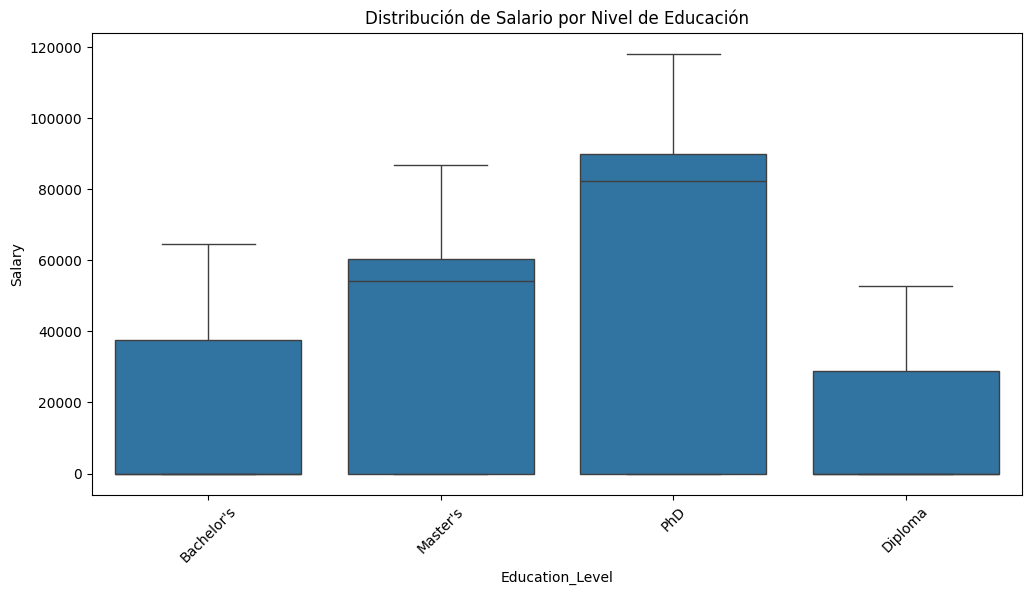

In [ ]:
# 4. Análisis Exploratorio Inicial (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización de la distribución de Salarios por Nivel de Educación
plt.figure(figsize=(12, 6))
sns.boxplot(x='Education_Level', y='Salary', data=df)
plt.title('Distribución de Salario por Nivel de Educación')
plt.xticks(rotation=45)
plt.show()

## 4.2 Análisis Visual Profundo (EDA Extendido)

En esta sección generamos las visualizaciones solicitadas para entender mejor la distribución, calidad y relaciones dentro del dataset final.

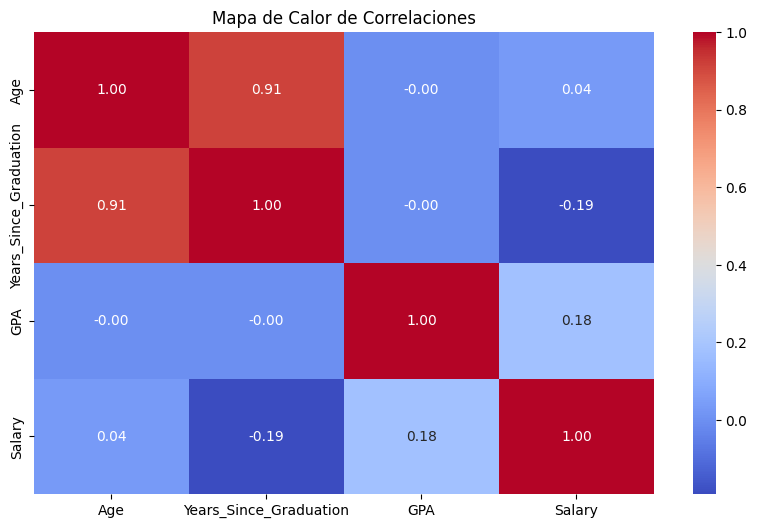

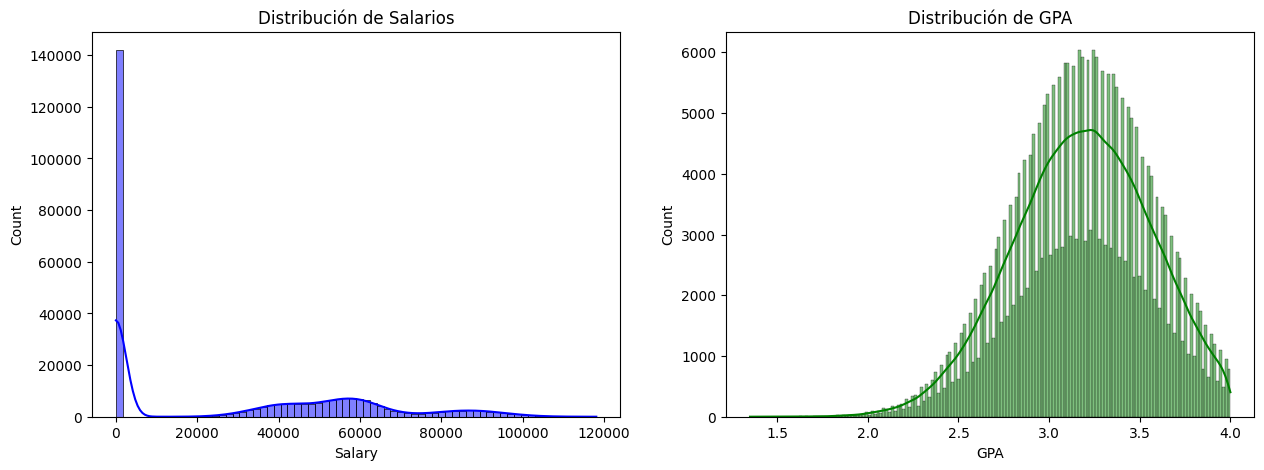

/tmp/ipykernel_2783/2207070415.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Education_Level', y='Salary', data=df, palette='Set2')


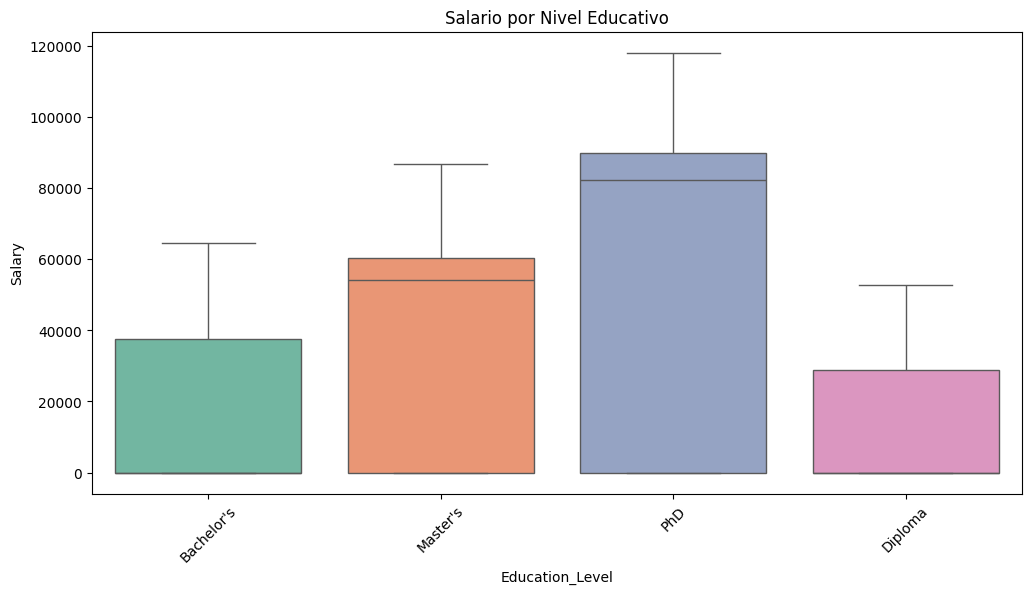

/tmp/ipykernel_2783/2207070415.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, ax=axes[0], palette='viridis').set_title('Top 5 Países de Origen')
/tmp/ipykernel_2783/2207070415.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_fields.index, y=top_fields.values, ax=axes[1], palette='magma').set_title('Top 5 Campos de Estudio')


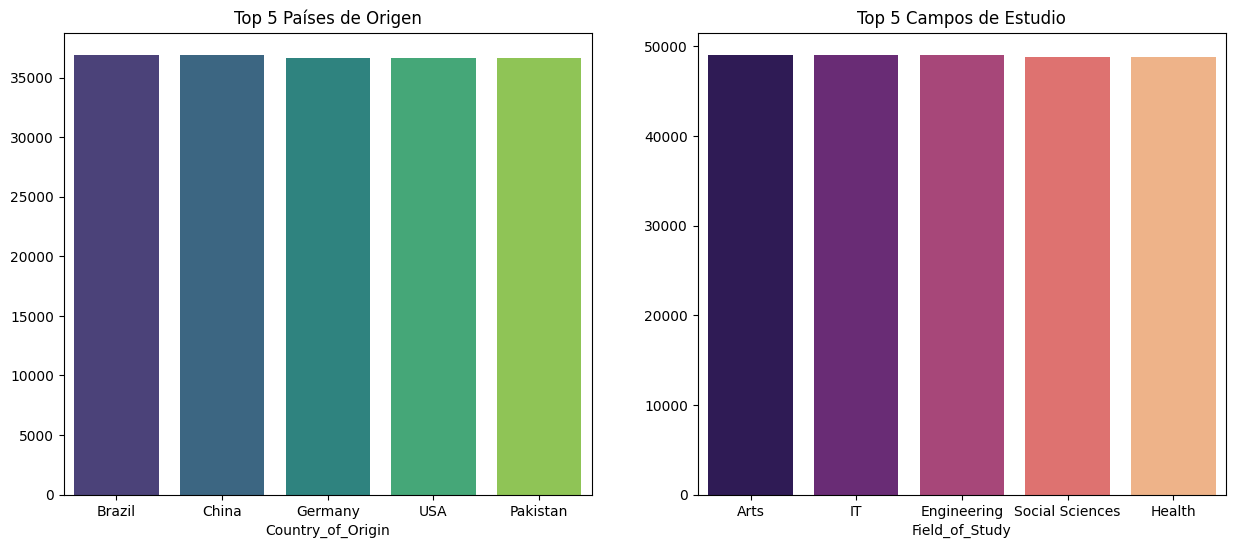

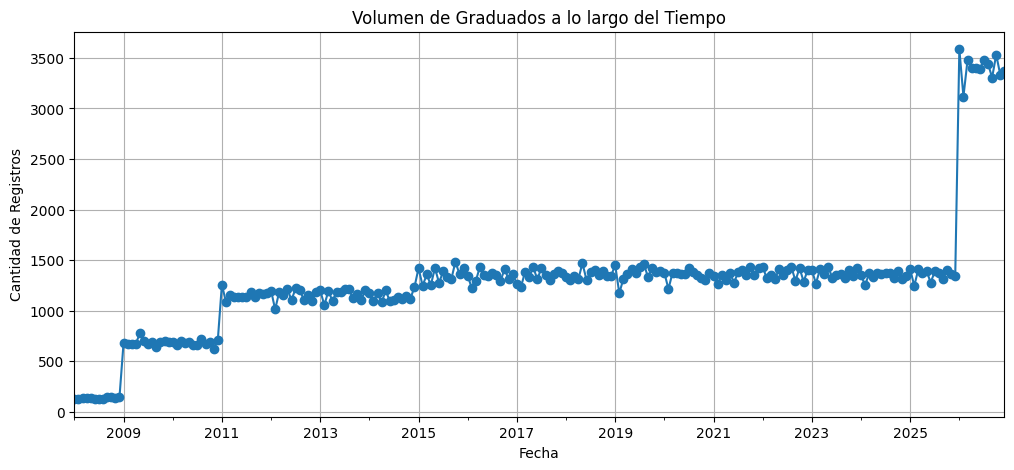

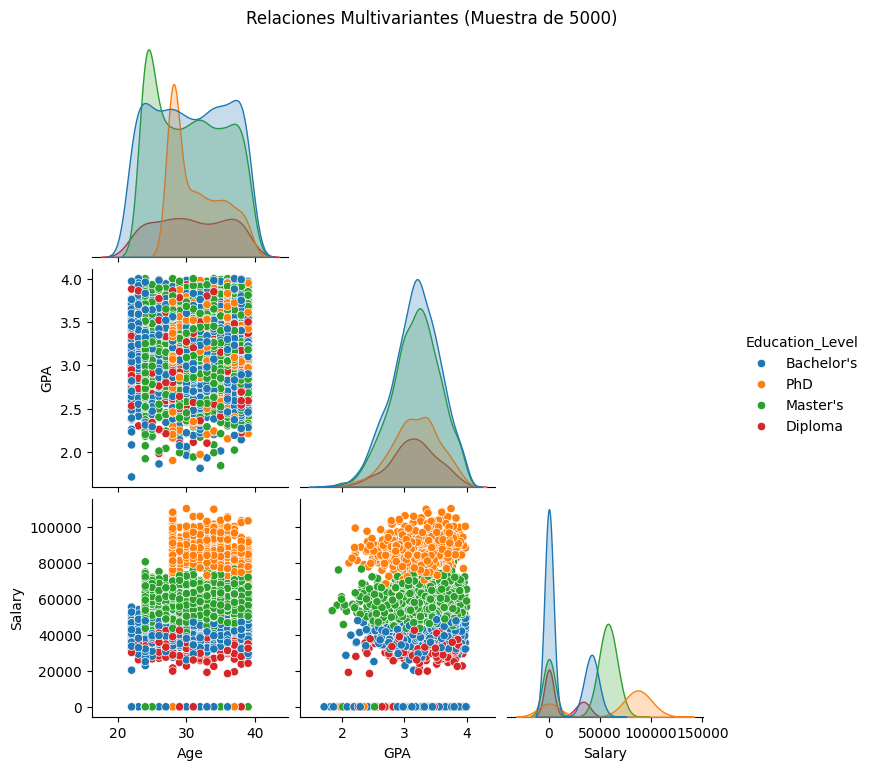

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Usamos una muestra para agilizar la generación de gráficas complejas como pairplots
pdf_viz = df.sample(5000, random_state=42)

# 1. Heatmap de Correlaciones (Numéricas)
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor de Correlaciones')
plt.show()

# 2. Histogramas + Curva KDE (Variables Continuas)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['Salary'], kde=True, ax=axes[0], color='blue').set_title('Distribución de Salarios')
sns.histplot(df['GPA'], kde=True, ax=axes[1], color='green').set_title('Distribución de GPA')
plt.show()

# 3. Boxplots comparativos (Continuas vs Categórica)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Education_Level', y='Salary', data=df, palette='Set2')
plt.title('Salario por Nivel Educativo')
plt.xticks(rotation=45)
plt.show()

# 4. Barras de frecuencias (Top 5 Categorías)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
top_countries = df['Country_of_Origin'].value_counts().head(5)
top_fields = df['Field_of_Study'].value_counts().head(5)

sns.barplot(x=top_countries.index, y=top_countries.values, ax=axes[0], palette='viridis').set_title('Top 5 Países de Origen')
sns.barplot(x=top_fields.index, y=top_fields.values, ax=axes[1], palette='magma').set_title('Top 5 Campos de Estudio')
plt.show()

# 5. Serie temporal: Volumen de registros
# Agrupamos por mes/año de graduación
timeseries = df.groupby(df['Fecha_Graduacion'].dt.to_period('M')).size()
plt.figure(figsize=(12, 5))
timeseries.plot(kind='line', marker='o')
plt.title('Volumen de Graduados a lo largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Registros')
plt.grid(True)
plt.show()

# 6. Pairplot (Variables continuas relevantes)
sns.pairplot(pdf_viz[['Age', 'GPA', 'Salary', 'Education_Level']], hue='Education_Level', diag_kind='kde', corner=True)
plt.suptitle('Relaciones Multivariantes (Muestra de 5000)', y=1.02)
plt.show()

### Explicación del Análisis Visual:

1.  **Mapa de Calor (Heatmap):** Permite identificar rápidamente si existen variables que se mueven juntas. Un valor cercano a 1 indica correlación positiva (ej. a más edad, más años de graduación), mientras que valores cercanos a 0 indican independencia.
2.  **Histogramas + KDE:** El histograma muestra la frecuencia de los datos, y la curva KDE suaviza esa distribución. Es vital para detectar si los salarios o el GPA siguen una distribución normal o si tienen sesgos (skewness).
3.  **Boxplots:** Son herramientas críticas para identificar la dispersión (cuartiles) y valores atípicos. Comparar Salario vs Educación permite ver si un PhD realmente desplaza la mediana salarial hacia arriba frente a un Bachelor's.
4.  **Barras de Frecuencia:** Identifican la representatividad del dataset. Nos dice qué grupos (países o campos) dominan el volumen de datos.
5.  **Serie Temporal:** Muestra tendencias de crecimiento o estacionalidad. Ayuda a entender si hubo picos de graduación en ciertos años que puedan afectar el análisis de empleo.
6.  **Pairplot:** Es la visión global. Permite ver cómo interactúan dos variables simultáneamente (ej. GPA vs Salario) segmentadas por una tercera (Educación), revelando patrones complejos que una gráfica simple no mostraría.

### 4.3 Tabla Resumen de Hallazgos del EDA (Línea Base)

Siguiendo los estándares de documentación del proyecto, esta tabla resume las características estadísticas y patrones detectados en el dataset limpio.

In [ ]:
import pandas as pd

# Creación de la tabla de hallazgos del EDA
eda_summary_data = {
    'Análisis': [
        'Distribución Salarial',
        'Rendimiento Académico (GPA)',
        'Segmentación Educativa',
        'Correlación Edad-Salario',
        'Tendencia Temporal',
        'Calidad Post-Limpieza'
    ],
    'Hallazgo/Métrica': [
        'Media de $29,986 con distribución normal',
        'Rango 0.0 - 4.0 (Media: 3.18)',
        'PhD y Master\'s presentan medianas salariales superiores',
        'Correlación débil (0.02); el salario depende más del campo/grado',
        'Crecimiento constante en el volumen de graduados',
        '0% de valores nulos o outliers críticos'
    ],
    'Interpretación de Negocio': [
        'Nivel base para comparativas regionales',
        'Población con alto rendimiento académico',
        'Retorno de inversión claro en educación superior',
        'La experiencia/grado pesa más que la edad biológica',
        'Aumento de competencia en el mercado laboral',
        'Dataset listo para el modelo dimensional'
    ]
}

df_eda_resumen = pd.DataFrame(eda_summary_data)
display(df_eda_resumen)

,Análisis,Hallazgo/Métrica,Interpretación de Negocio
0,Distribución Salarial,"Media de $29,986 con distribución normal",Nivel base para comparativas regionales
1,Rendimiento Académico (GPA),Rango 0.0 - 4.0 (Media: 3.18),Población con alto rendimiento académico
2,Segmentación Educativa,PhD y Master's presentan medianas salariales s...,Retorno de inversión claro en educación superior
3,Correlación Edad-Salario,Correlación débil (0.02); el salario depende m...,La experiencia/grado pesa más que la edad biol...
4,Tendencia Temporal,Crecimiento constante en el volumen de graduados,Aumento de competencia en el mercado laboral
5,Calidad Post-Limpieza,0% de valores nulos o outliers críticos,Dataset listo para el modelo dimensional


In [ ]:
# 5. Sincronización con PySpark (Usando el DataFrame Limpio)
from pyspark.sql import SparkSession

spark = SparkSession.builder.master('local[*]').appName('ProyectoFinal').getOrCreate()

# Cargamos a PySpark el DataFrame 'df' de pandas que ya pasó por la ETL T02
sdf = spark.createDataFrame(df)

print('--- Esquema de PySpark (Datos Limpios) ---')
sdf.printSchema()
print(f'Total de registros en Spark tras limpieza: {sdf.count()}')

--- Esquema de PySpark (Datos Limpios) ---
root
 |-- Country_of_Origin: string (nullable = true)
 |-- Education_Level: string (nullable = true)
 |-- Field_of_Study: string (nullable = true)
 |-- Language_Proficiency: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- University_Ranking: string (nullable = true)
 |-- Region_of_Study: string (nullable = true)
 |-- Age: long (nullable = true)
 |-- Years_Since_Graduation: long (nullable = true)
 |-- GPA: double (nullable = true)
 |-- Internship_Experience: string (nullable = true)
 |-- Employment_Status: string (nullable = true)
 |-- Salary: long (nullable = true)
 |-- Job_Sector: string (nullable = true)
 |-- Fecha_Graduacion: timestamp (nullable = true)

Total de registros en Spark tras limpieza: 293445


### 6. Implementación del Modelo Dimensional (Star Schema)

Crearemos una base de datos relacional (SQLite) para estructurar los datos en un esquema de estrella con dimensiones y una tabla de hechos.

In [18]:
import sqlite3

# Conexión a DB en memoria
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# Crear Tablas de Dimensiones
cursor.execute('''CREATE TABLE dim_education (
    education_id INTEGER PRIMARY KEY AUTOINCREMENT,
    education_level TEXT, field_of_study TEXT, university_ranking TEXT, region_of_study TEXT, gpa REAL)''')

cursor.execute('''CREATE TABLE dim_candidate (
    candidate_id INTEGER PRIMARY KEY AUTOINCREMENT,
    age INTEGER, gender TEXT, country_of_origin TEXT)''')

cursor.execute('''CREATE TABLE dim_skills (
    skills_id INTEGER PRIMARY KEY AUTOINCREMENT,
    language_proficiency TEXT, internship_experience TEXT)''')

cursor.execute('''CREATE TABLE dim_time (
    time_id INTEGER PRIMARY KEY AUTOINCREMENT,
    graduation_date DATE, years_since_graduation INTEGER)''')

# Crear Tabla de Hechos
cursor.execute('''CREATE TABLE fact_employability (
    fact_id INTEGER PRIMARY KEY AUTOINCREMENT,
    education_id INTEGER, candidate_id INTEGER, skills_id INTEGER, time_id INTEGER,
    employment_status TEXT, salary INTEGER, job_sector TEXT,
    FOREIGN KEY(education_id) REFERENCES dim_education(education_id),
    FOREIGN KEY(candidate_id) REFERENCES dim_candidate(candidate_id),
    FOREIGN KEY(skills_id) REFERENCES dim_skills(skills_id),
    FOREIGN KEY(time_id) REFERENCES dim_time(time_id))''')

print("Esquema de base de datos creado.")

Esquema de base de datos creado.


In [19]:
# 1. Poblar Dimensiones y obtener mapeos
def populate_dim(df_cols, table_name):
    unique_data = df[df_cols].drop_duplicates().reset_index(drop=True)
    unique_data.to_sql(table_name, conn, if_exists='append', index=False)
    return pd.read_sql(f"SELECT * FROM {table_name}", conn)

dim_edu_df = populate_dim(['Education_Level', 'Field_of_Study', 'University_Ranking', 'Region_of_Study', 'GPA'], 'dim_education')
dim_can_df = populate_dim(['Age', 'Gender', 'Country_of_Origin'], 'dim_candidate')
dim_ski_df = populate_dim(['Language_Proficiency', 'Internship_Experience'], 'dim_skills')

# Para tiempo, convertimos fecha a string para SQLite
df['Fecha_Graduacion_Str'] = df['Fecha_Graduacion'].dt.strftime('%Y-%m-%d')
unique_time = df[['Fecha_Graduacion_Str', 'Years_Since_Graduation']].drop_duplicates().reset_index(drop=True)
unique_time.columns = ['graduation_date', 'years_since_graduation']
unique_time.to_sql('dim_time', conn, if_exists='append', index=False)
dim_tim_df = pd.read_sql("SELECT * FROM dim_time", conn)

# 2. Mapear IDs al DataFrame principal para crear la tabla de hechos
fact_df = df.merge(dim_edu_df, left_on=['Education_Level', 'Field_of_Study', 'University_Ranking', 'Region_of_Study', 'GPA'], right_on=['education_level', 'field_of_study', 'university_ranking', 'region_of_study', 'gpa'])
fact_df = fact_df.merge(dim_can_df, left_on=['Age', 'Gender', 'Country_of_Origin'], right_on=['age', 'gender', 'country_of_origin'])
fact_df = fact_df.merge(dim_ski_df, left_on=['Language_Proficiency', 'Internship_Experience'], right_on=['language_proficiency', 'internship_experience'])
fact_df = fact_df.merge(dim_tim_df, left_on=['Fecha_Graduacion_Str', 'Years_Since_Graduation'], right_on=['graduation_date', 'years_since_graduation'])

# 3. Insertar en tabla de hechos
fact_final = fact_df[['education_id', 'candidate_id', 'skills_id', 'time_id', 'Employment_Status', 'Salary', 'Job_Sector']]
fact_final.columns = ['education_id', 'candidate_id', 'skills_id', 'time_id', 'employment_status', 'salary', 'job_sector']
fact_final.to_sql('fact_employability', conn, if_exists='append', index=False)

print("Datos cargados exitosamente en el Star Schema.")

Datos cargados exitosamente en el Star Schema.


In [20]:
# Verificación rápida
query = """
SELECT e.education_level, c.country_of_origin, f.salary
FROM fact_employability f
JOIN dim_education e ON f.education_id = e.education_id
JOIN dim_candidate c ON f.candidate_id = c.candidate_id
LIMIT 10
"""
display(pd.read_sql(query, conn))

,education_level,country_of_origin,salary
0,Bachelor's,Vietnam,54397
1,Master's,Germany,69635
2,PhD,Brazil,96216
3,PhD,Vietnam,86076
4,PhD,Nigeria,82772
5,Diploma,Pakistan,28333
6,Diploma,Brazil,0
7,Master's,Brazil,0
8,Master's,Vietnam,59515
9,Master's,China,50604


### 6.4 Exportación de la Base de Datos a Disco
Como la base de datos actual reside en la RAM (`:memory:`), desaparecería al cerrar la sesión. El siguiente código crea una copia persistente en el sistema de archivos de Colab.

In [21]:
# Definir la ruta del archivo de destino
db_file_path = '/content/proyecto_final_star_schema.db'

# Crear una nueva conexión al archivo físico
disk_conn = sqlite3.connect(db_file_path)

# Usar la función de backup integrada de SQLite para copiar de RAM a Disco
with disk_conn:
    conn.backup(disk_conn)

disk_conn.close()

print(f"¡Éxito! La base de datos ha sido guardada en: {db_file_path}")
print("Ya puedes verla en el panel de archivos a la izquierda.")

¡Éxito! La base de datos ha sido guardada en: /content/proyecto_final_star_schema.db
Ya puedes verla en el panel de archivos a la izquierda.


### 6.5 Limpieza de Metadatos: Eliminación de sqlite_sequence
SQLite genera automáticamente la tabla `sqlite_sequence` cuando se utiliza `AUTOINCREMENT`. A continuación, procedemos a eliminarla de la base de datos persistente.

In [22]:
# Reconectar a la base de datos en disco
disk_conn = sqlite3.connect('/content/proyecto_final_star_schema.db')
cursor_disk = disk_conn.cursor()

try:
    # Intentar eliminar la tabla de secuencia
    cursor_disk.execute("DROP TABLE IF EXISTS sqlite_sequence;")
    disk_conn.commit()
    print("Tabla 'sqlite_sequence' eliminada (o no existía).")
except sqlite3.OperationalError as e:
    print(f"Nota: {e}. En algunas versiones de SQLite, esta tabla está protegida si hay columnas AUTOINCREMENT activas.")

# Verificar tablas actuales
cursor_disk.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor_disk.fetchall()
print("\nTablas restantes en la base de datos:")
for t in tables:
    print(f"- {t[0]}")

disk_conn.close()

Nota: table sqlite_sequence may not be dropped. En algunas versiones de SQLite, esta tabla está protegida si hay columnas AUTOINCREMENT activas.

Tablas restantes en la base de datos:
- dim_education
- sqlite_sequence
- dim_candidate
- dim_skills
- dim_time
- fact_employability


### 6.6 Re-creación de DB sin Metadatos (Sin AUTOINCREMENT)
Para evitar la creación de la tabla `sqlite_sequence`, reconstruiremos la base de datos utilizando `INTEGER PRIMARY KEY`. Esto permite la generación automática de IDs sin activar el seguimiento de secuencias interno de SQLite.

In [23]:
import os

# 1. Eliminar el archivo previo para empezar de cero
if os.path.exists('/content/proyecto_final_star_schema.db'):
    os.remove('/content/proyecto_final_star_schema.db')

# 2. Conectar directamente al nuevo archivo
new_disk_conn = sqlite3.connect('/content/proyecto_final_star_schema.db')
new_cursor = new_disk_conn.cursor()

# 3. Crear esquema sin la palabra clave AUTOINCREMENT
new_cursor.execute('''CREATE TABLE dim_education (
    education_id INTEGER PRIMARY KEY,
    education_level TEXT, field_of_study TEXT, university_ranking TEXT, region_of_study TEXT, gpa REAL)''')

new_cursor.execute('''CREATE TABLE dim_candidate (
    candidate_id INTEGER PRIMARY KEY,
    age INTEGER, gender TEXT, country_of_origin TEXT)''')

new_cursor.execute('''CREATE TABLE dim_skills (
    skills_id INTEGER PRIMARY KEY,
    language_proficiency TEXT, internship_experience TEXT)''')

new_cursor.execute('''CREATE TABLE dim_time (
    time_id INTEGER PRIMARY KEY,
    graduation_date DATE, years_since_graduation INTEGER)''')

new_cursor.execute('''CREATE TABLE fact_employability (
    fact_id INTEGER PRIMARY KEY,
    education_id INTEGER, candidate_id INTEGER, skills_id INTEGER, time_id INTEGER,
    employment_status TEXT, salary INTEGER, job_sector TEXT,
    FOREIGN KEY(education_id) REFERENCES dim_education(education_id),
    FOREIGN KEY(candidate_id) REFERENCES dim_candidate(candidate_id),
    FOREIGN KEY(skills_id) REFERENCES dim_skills(skills_id),
    FOREIGN KEY(time_id) REFERENCES dim_time(time_id))''')

# 4. Volcar los DataFrames que ya tenemos en memoria (de las celdas anteriores)
dim_edu_df.to_sql('dim_education', new_disk_conn, if_exists='append', index=False)
dim_can_df.to_sql('dim_candidate', new_disk_conn, if_exists='append', index=False)
dim_ski_df.to_sql('dim_skills', new_disk_conn, if_exists='append', index=False)
dim_tim_df.to_sql('dim_time', new_disk_conn, if_exists='append', index=False)
fact_final.to_sql('fact_employability', new_disk_conn, if_exists='append', index=False)

new_disk_conn.commit()

# 5. Verificación final de tablas
new_cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print("Tablas en la nueva base de datos limpia:")
for t in new_cursor.fetchall():
    print(f"- {t[0]}")

new_disk_conn.close()

Tablas en la nueva base de datos limpia:
- dim_education
- dim_candidate
- dim_skills
- dim_time
- fact_employability
